### Import librairies

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtr, ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

### Custom functions

In [ ]:
# Functions used across the notebook. They read notebook variables defined in the Inputs section,
# so they can be defined here and called once that section has run.

# --- Pricing (vectorised Hagan SABR vol + Black-76) ---
def sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. (2002) lognormal implied vol, vectorised over K."""
    K = np.asarray(K, dtype=float)
    fk_pow = (F * K) ** (0.5 * (1 - beta))
    log_fk = np.log(F / K)
    z = nu / alpha * fk_pow * log_fk
    x = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    small = np.abs(z) < 1e-7
    z_over_x = np.where(small, 1.0, z / np.where(small, 1.0, x))
    denom = fk_pow * (1 + (1 - beta) ** 2 / 24 * log_fk ** 2 + (1 - beta) ** 4 / 1920 * log_fk ** 4)
    corr = 1 + ((1 - beta) ** 2 / 24 * alpha ** 2 / fk_pow ** 2
                + 0.25 * rho * beta * nu * alpha / fk_pow
                + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T
    return alpha / denom * z_over_x * corr


def black_price(F, K, T, vol, is_call, r=0.0):
    """Discounted Black-76 price, vectorised over K. T <= 0 returns intrinsic."""
    K = np.asarray(K, dtype=float)
    if T <= 0:
        return np.where(is_call, np.maximum(F - K, 0.0), np.maximum(K - F, 0.0))
    sd = vol * np.sqrt(T)
    d1 = np.log(F / K) / sd + 0.5 * sd
    call = F * ndtr(d1) - K * ndtr(d1 - sd)
    return np.exp(-r * T) * np.where(is_call, call, call - (F - K))


def portfolio_pv(weights, F, T_left, alpha=None, beta=None, rho=None, nu=None):
    """PV of a portfolio of options (weights indexed by (option_type, strike)) under SABR (pricing parameters by default)."""
    alpha = pricing_alpha if alpha is None else alpha
    beta = pricing_beta if beta is None else beta
    rho = pricing_rho if rho is None else rho
    nu = pricing_nu if nu is None else nu
    strikes = weights.index.get_level_values("strike").to_numpy()
    is_call = weights.index.get_level_values("option_type").to_numpy() == "call"
    vol = sabr_vol(F, strikes, max(T_left, 1e-12), alpha, beta, rho, nu)
    return weights.to_numpy() @ black_price(F, strikes, T_left, vol, is_call, r)


# --- Greeks ---
def bartlett_bumped_pvs(weights, F, T_left, alpha, rel_bump=1e-4):
    """PVs at F - h, F, F + h, with alpha moving along its expected shift dalpha = rho * nu / F^beta * dF (Bartlett 2006)."""
    h = F * rel_bump
    d_alpha = pricing_rho * pricing_nu / F ** pricing_beta * h
    down = portfolio_pv(weights, F - h, T_left, alpha - d_alpha)
    base = portfolio_pv(weights, F, T_left, alpha)
    up = portfolio_pv(weights, F + h, T_left, alpha + d_alpha)
    return down, base, up, h


def greeks(weights, F, T_left, alpha=None):
    """Headline greeks of a portfolio under the pricing SABR parameters:
    pv, bartlett_delta (dPV/dF along the SABR backbone), delta_cash (delta * F), gamma_cash (Gamma * F^2 / 100,
    P&L per 1% move squared), theta (PV change over one day, spot and vol unchanged), vega (PV change for alpha +1 vol
    point), rho_risk (PV change for rho + rho_bump) and nu_risk (PV change for nu + nu_bump)."""
    alpha = pricing_alpha if alpha is None else alpha
    down, base, up, h = bartlett_bumped_pvs(weights, F, T_left, alpha)
    delta = (up - down) / (2 * h)
    return {
        "pv": base,
        "bartlett_delta": delta,
        "delta_cash": delta * F,
        "gamma_cash": (up - 2 * base + down) / h ** 2 * F ** 2 / 100,
        "theta": portfolio_pv(weights, F, T_left - one_day, alpha) - base,
        "vega": portfolio_pv(weights, F, T_left, alpha + vega_bump) - base,
        "rho_risk": portfolio_pv(weights, F, T_left, alpha, rho=pricing_rho + rho_bump) - base,
        "nu_risk": portfolio_pv(weights, F, T_left, alpha, nu=pricing_nu + nu_bump) - base,
    }


def book_greeks(book, F, alpha=None):
    """Greeks of every leg of the book (dict name -> (weights, T_left)) and of the total, one column per leg."""
    table = pd.DataFrame({name: greeks(weights, F, T_left, alpha) for name, (weights, T_left) in book.items()})
    table["total"] = table.sum(axis=1)
    return table


# --- Variance swap strip ---
def delta_to_strike(delta, F, T_left):
    """Strike of a Black-76 delta (negative: put delta, positive: call delta) at the SABR ATM vol."""
    atm_sd = sabr_vol(F, F, T_left, pricing_alpha, pricing_beta, pricing_rho, pricing_nu) * np.sqrt(T_left)
    delta = np.asarray(delta, dtype=float)
    call_delta = np.where(delta < 0, 1 + delta / np.exp(-r * T_left), delta / np.exp(-r * T_left))
    return F * np.exp(-ndtri(call_delta) * atm_sd + 0.5 * atm_sd ** 2)


def variance_swap_strip(strikes, F, T_left):
    """Option strip replicating the log contract 2/T * [(S - S_star) / S_star - ln(S / S_star)] (Demeterfi et al.).

    Weights are the kinks of the piecewise-linear interpolant of the payoff on the strikes, with one ghost node on each
    side so the boundary strikes carry weight. Puts below S_star (grid node closest to F), calls from it upwards.
    """
    dK = strikes[1] - strikes[0]
    S_star = strikes[np.argmin(np.abs(strikes - F))]
    nodes = np.concatenate([[strikes[0] - dK], strikes, [strikes[-1] + dK]])
    payoff = 2 / T_left * ((nodes - S_star) / S_star - np.log(nodes / S_star))
    slopes = np.diff(payoff) / np.diff(nodes)
    index = pd.MultiIndex.from_arrays([np.where(strikes < S_star, "put", "call"), strikes], names=["option_type", "strike"])
    return pd.Series(np.diff(slopes), index=index)


def size_to_theta(weights, F, T_left, theta):
    """Scale a portfolio so its headline one-day theta at F equals theta."""
    return weights * theta / greeks(weights, F, T_left)["theta"]

### Inputs

In [ ]:
# Market parameters
F0 = 100.0                                  # forward (spot = forward, no carry)
r = 0.00                                    # risk-free rate
one_day = 1 / 252                           # theta horizon (years)

# SABR pricing parameters (Hagan 2002, lognormal backbone)
pricing_alpha = 0.20                        # initial vol level (~ ATM lognormal vol when beta = 1)
pricing_beta = 1.0                          # CEV exponent: 1 = lognormal, 0 = normal
pricing_rho = -0.90                         # spot / vol correlation (equity skew)
pricing_nu = 0.80                           # vol of vol

# Greek bumps
vega_bump = 0.01                            # alpha + 1 vol point
rho_bump = 0.10                             # rho + 0.10
nu_bump = 0.10                              # nu + 0.10

# Variance swap leg
vs_maturity = 21 / 252                      # 1 month
vs_min_delta_strike = -0.01                 # put delta of the lowest strike of the strip
vs_max_delta_strike = 0.01                  # call delta of the highest strike of the strip
vs_n_options = 100                          # number of strikes in the strip
vs_theta = -250_000                         # headline one-day theta of the variance swap leg

# ATM hedge leg
atm_maturity = 1 / 252                      # 1 day
atm_option_type = "call"                    # ATM call or put (same gamma)
atm_theta = 250_000                         # headline one-day theta of the ATM leg

# Spot bumps (relative) for the risk ladder
spot_bumps = [-0.10, -0.075, -0.05, -0.04, -0.03, -0.02, -0.015, -0.01, -0.005, 0.0,
              0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10]

### Portfolio construction

In [ ]:
# Variance swap leg: strip of OTM options between the delta strike bounds, sized to vs_theta
K_lower, K_upper = delta_to_strike([vs_min_delta_strike, vs_max_delta_strike], F0, vs_maturity)
vs_strikes = np.linspace(K_lower, K_upper, vs_n_options)
vs_weights = size_to_theta(variance_swap_strip(vs_strikes, F0, vs_maturity), F0, vs_maturity, vs_theta)

# ATM leg: one option struck at the forward, sized to atm_theta
atm_index = pd.MultiIndex.from_tuples([(atm_option_type, F0)], names=["option_type", "strike"])
atm_weights = size_to_theta(pd.Series([1.0], index=atm_index), F0, atm_maturity, atm_theta)

book = {
    "variance_swap": (vs_weights, vs_maturity),
    "atm_option": (atm_weights, atm_maturity),
}

# Fair variance implied by the strip: PV of the unit strip ~ E[log contract] = fair variance (S_star ~ F0, no carry)
unit_strip = variance_swap_strip(vs_strikes, F0, vs_maturity)
S_star = vs_strikes[np.argmin(np.abs(vs_strikes - F0))]
vs_scale = (vs_weights / unit_strip).iloc[0]                                    # strip = vs_scale x unit strip
vs_fair_vol = np.sqrt(greeks(unit_strip, F0, vs_maturity)["pv"])
vs_variance_notional = vs_scale / 1e4                                           # P&L per variance point (vol in %, squared)
vs_vega_notional = vs_variance_notional * 2 * vs_fair_vol * 100                 # P&L per vol point at the fair strike

print(f"VS strike range: [{K_lower:.2f}, {K_upper:.2f}], S* = {S_star:.2f}, {vs_n_options} strikes")
print(f"VS fair vol = {vs_fair_vol:.2%}, variance notional = {vs_variance_notional:_.0f}, vega notional = {vs_vega_notional:_.0f}")
print(f"ATM {atm_option_type}: strike = {F0:.2f}, SABR vol = {sabr_vol(F0, F0, atm_maturity, pricing_alpha, pricing_beta, pricing_rho, pricing_nu):.2%}, "
      f"quantity = {atm_weights.iloc[0]:_.0f}")
display(pd.concat({name: w for name, (w, _) in book.items()}, names=["leg"]).to_frame("quantity"))

VS strike range: [87.62, 114.50], S* = 100.11, 100 strikes
VS fair vol = 20.09%, variance notional = 13_253, vega notional = 532_588
ATM call: strike = 100.00, SABR vol = 20.00%, quantity = -497_491


quantity
leg           option_type strike          
variance_swap put         87.62    112_482
                          87.89    111_788
                          88.17    111_100
                          88.44    110_419
                          88.71    109_744
...                                    ...
              call        113.7     66_816
                          114       66_498
                          114.2     66_182
                          114.5     65_869
atm_option    call        100     -497_491

[101 rows x 1 columns]

### t0 greeks

In [ ]:
t0_greeks = book_greeks(book, F0)
display(t0_greeks)

,variance_swap,atm_option,total
pv,5_350_802,-250_000,5_100_802
bartlett_delta,-337_511,-245_497,-583_007
delta_cash,-33_751_073,-24_549_676,-58_300_749
gamma_cash,31_161_096,-15_743_774,15_417_322
theta,-250_000,250_000,-9.313e-10
vega,526_932,-12_498,514_434
rho_risk,10_596,-17.46,10_578
nu_risk,19_444,7.487,19_452


### Greeks at spot bumps
The spot is bumped with alpha unchanged (sticky SABR parameters: the smile moves with the forward along the SABR backbone).

In [ ]:
spot_ladder = pd.concat({f"{b:+.1%}": book_greeks(book, F0 * (1 + b)) for b in spot_bumps}, names=["spot_bump"])

# One ladder per leg: rows = greek, columns = spot bump
for leg in ["variance_swap", "atm_option", "total"]:
    print(leg)
    display(spot_ladder[leg].unstack("spot_bump").loc[t0_greeks.index, [f"{b:+.1%}" for b in spot_bumps]])

variance_swap


spot_bump,-10.0%,-7.5%,-5.0%,-4.0%,-3.0%,-2.0%,-1.5%,-1.0%,-0.5%,+0.0%,+0.5%,+1.0%,+1.5%,+2.0%,+3.0%,+4.0%,+5.0%,+7.5%,+10.0%
pv,20_778_449,13_990_551,9_120_977,7_729_861,6_658_874,5_907_012,5_650_098,5_472_050,5_372_444,5_350_802,5_406_605,5_539_283,5_748_220,6_032_746,6_825_585,7_911_115,9_281_271,13_883_306,19_993_910
bartlett_delta,-3_334_213,-2_652_526,-1_898_548,-1_587_311,-1_274_013,-960_396,-803_915,-647_855,-492_347,-337_511,-183_457,-30_290,121_885,272_964,571_374,863_920,1_149_356,1_821_569,2_412_878
delta_cash,-300_079_152,-245_358_635,-180_362_059,-152_381_895,-123_579_292,-94_118_794,-79_185_675,-64_137_683,-48_988_552,-33_751_073,-18_437_382,-3_059_288,12_371_360,27_842_292,58_851_507,89_847_644,120_682_389,195_818_644,265_416_577
gamma_cash,18_280_310,23_412_799,27_162_065,28_289_332,29_231_194,30_009_755,30_344_651,30_646_703,30_918_195,31_161_096,31_376_980,31_566_934,31_731_484,31_870_522,32_068_196,32_145_401,32_078_009,31_082_367,28_647_191
theta,-146_914,-188_133,-218_168,-227_174,-234_683,-240_877,-243_536,-245_931,-248_081,-250_000,-251_702,-253_196,-254_486,-255_571,-257_095,-257_654,-257_057,-248_963,-229_368
vega,326_543,407_908,466_088,483_393,497_786,509_630,514_702,519_258,523_327,526_932,530_089,532_802,535_064,536_859,538_921,538_640,535_552,512_529,465_018
rho_risk,46_207,37_087,26_451,22_555,19_023,15_879,14_447,13_098,11_819,10_596,9_408,8_233,7_045,5_816,3_119,-80.85,-3_947,-16_620,-31_178
nu_risk,-35_056,-21_527,-5_596,415.2,5_972,10_999,13_306,15_478,17_521,19_444,21_261,22_989,24_651,26_271,29_503,32_927,36_766,48_840,62_903


atm_option


spot_bump,-10.0%,-7.5%,-5.0%,-4.0%,-3.0%,-2.0%,-1.5%,-1.0%,-0.5%,+0.0%,+0.5%,+1.0%,+1.5%,+2.0%,+3.0%,+4.0%,+5.0%,+7.5%,+10.0%
pv,-6.518e-21,-1.723e-08,-0.3971,-33.07,-969.5,-11_904,-31_668,-71_968,-142_409,-250_000,-396_469,-577_849,-786_387,-1_013_399,-1_495_482,-1_990_319,-2_487_485,-3_731_180,-4_974_906
bartlett_delta,-5.823e-20,-1.086e-07,-1.607,-108,-2_481,-23_050,-52_543,-101_243,-168_136,-245_497,-321_675,-386_218,-433_731,-464_399,-490_803,-496_547,-497_395,-497_491,-497_491
delta_cash,-5.241e-18,-1.005e-05,-152.6,-10_366,-240_675,-2_258_916,-5_175_453,-10_023_026,-16_729_523,-24_549_676,-32_328_309,-39_008_012,-44_023_741,-47_368_647,-50_552_725,-51_640_914,-52_226_433,-53_480_232,-54_723_969
gamma_cash,-4.185e-17,-5.776e-05,-567.5,-30_887,-551_372,-3_750_705,-7_096_506,-11_052_076,-14_355_937,-15_743_774,-14_743_199,-11_913_568,-8_388_711,-5_193_834,-1_399_199,-247_494,-30_299,-42.31,-0.006519
theta,6.518e-21,1.723e-08,0.3971,33.07,969.5,11_904,31_668,71_968,142_409,250_000,147_724,80_358,40_152,18_418,3_011,356.8,31.42,0.02359,4.935e-06
vega,-3.578e-18,-3.186e-07,-0.8922,-37.12,-550.8,-3_317,-6_018,-9_084,-11_546,-12_498,-11_643,-9_427,-6_695,-4_206,-1_187,-224.2,-29.85,-0.05501,-2.563e-05
rho_risk,-4.006e-19,-4.628e-08,-0.1439,-5.411,-65.28,-274.4,-378.2,-384.6,-250.6,-17.46,211.3,344.5,358,288.9,110.6,24.55,3.514,0.006078,2.114e-06
nu_risk,6.327e-21,1.21e-08,0.1052,4.734,63.68,285,400.5,412,267.1,7.487,-252.5,-408,-427.4,-349.7,-139.3,-32.63,-5.009,-0.01113,-5.564e-06


total


spot_bump,-10.0%,-7.5%,-5.0%,-4.0%,-3.0%,-2.0%,-1.5%,-1.0%,-0.5%,+0.0%,+0.5%,+1.0%,+1.5%,+2.0%,+3.0%,+4.0%,+5.0%,+7.5%,+10.0%
pv,20_778_449,13_990_551,9_120_976,7_729_828,6_657_904,5_895_108,5_618_430,5_400_082,5_230_034,5_100_802,5_010_136,4_961_434,4_961_832,5_019_347,5_330_103,5_920_795,6_793_786,10_152_126,15_019_004
bartlett_delta,-3_334_213,-2_652_526,-1_898_550,-1_587_419,-1_276_495,-983_446,-856_458,-749_098,-660_483,-583_007,-505_131,-416_508,-311_846,-191_435,80_571,367_372,651_961,1_324_078,1_915_387
delta_cash,-300_079_152,-245_358_635,-180_362_212,-152_392_262,-123_819_967,-96_377_710,-84_361_128,-74_160_709,-65_718_075,-58_300_749,-50_765_691,-42_067_300,-31_652_381,-19_526_355,8_298_782,38_206_730,68_455_957,142_338_412,210_692_608
gamma_cash,18_280_310,23_412_799,27_161_497,28_258_445,28_679_822,26_259_050,23_248_145,19_594_626,16_562_258,15_417_322,16_633_781,19_653_366,23_342_774,26_676_687,30_668_997,31_897_906,32_047_710,31_082_324,28_647_191
theta,-146_914,-188_133,-218_168,-227_141,-233_714,-228_973,-211_868,-173_963,-105_671,-9.313e-10,-103_979,-172_838,-214_334,-237_153,-254_084,-257_297,-257_026,-248_963,-229_368
vega,326_543,407_908,466_087,483_356,497_236,506_313,508_685,510_174,511_781,514_434,518_446,523_375,528_369,532_652,537_735,538_416,535_523,512_529,465_018
rho_risk,46_207,37_087,26_451,22_550,18_958,15_605,14_069,12_713,11_569,10_578,9_619,8_578,7_403,6_105,3_229,-56.3,-3_943,-16_620,-31_178
nu_risk,-35_056,-21_527,-5_596,420,6_036,11_284,13_707,15_890,17_788,19_452,21_008,22_581,24_224,25_921,29_363,32_894,36_761,48_840,62_903


### Greek profiles across spot

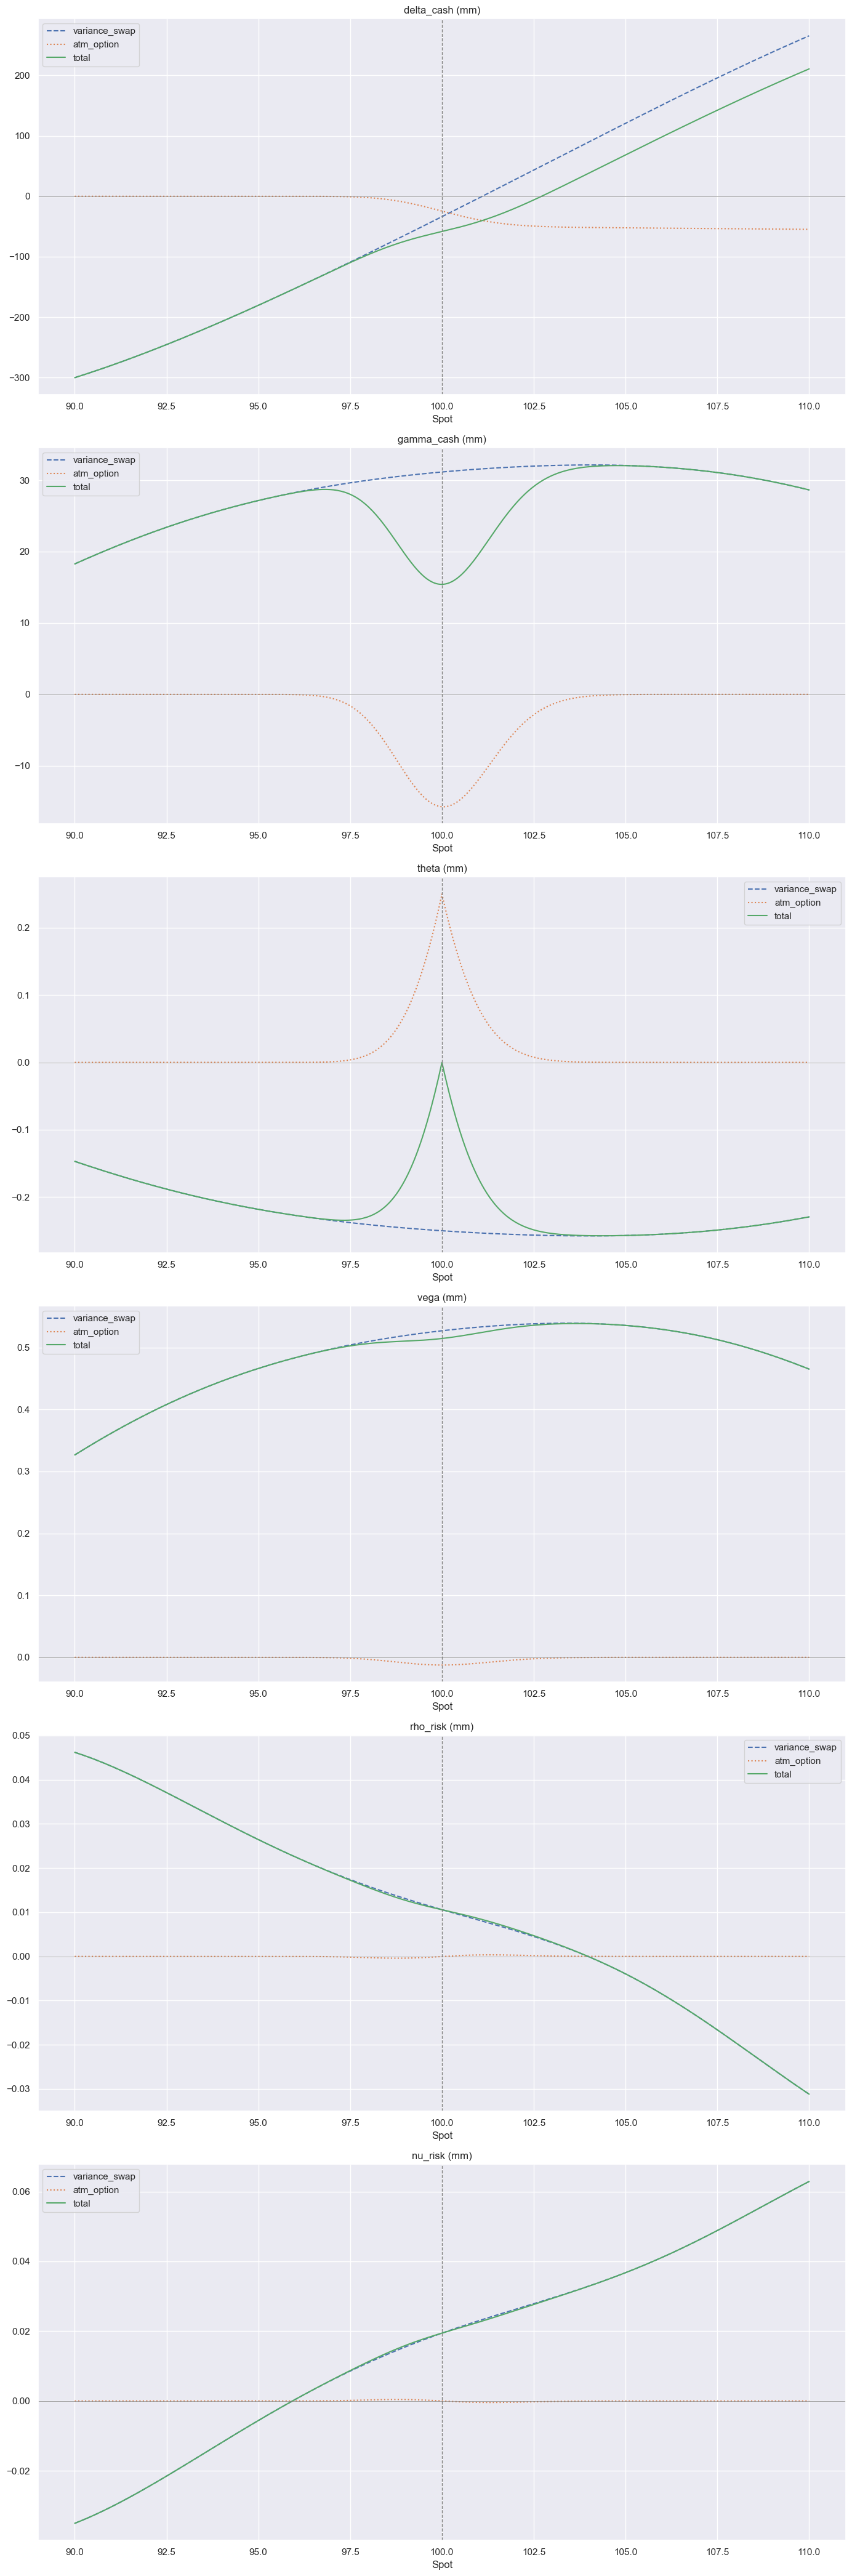

In [ ]:
# Same greeks on a fine spot grid, per leg and total
spot_grid = F0 * (1 + np.linspace(-0.10, 0.10, 401))
profile = pd.concat({F: book_greeks(book, F).stack() for F in spot_grid}, axis=1).T

plot_greeks = ["delta_cash", "gamma_cash", "theta", "vega", "rho_risk", "nu_risk"]
fig, axes = plt.subplots(len(plot_greeks), 1, figsize=(14, 7 * len(plot_greeks)))
for ax, name in zip(axes, plot_greeks):
    for leg, style in (("variance_swap", "--"), ("atm_option", ":"), ("total", "-")):
        ax.plot(spot_grid, profile[(name, leg)] / 1e6, linestyle=style, label=leg)
    ax.axvline(F0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{name} (mm)")
    ax.set_xlabel("Spot")
    ax.legend()
plt.tight_layout()
plt.show()

### Greeks after one day
The ATM option expires after one day, leaving the variance swap unhedged: greeks of the book one day later at each spot bump.

In [ ]:
# Legs expiring within the day are settled (cash) and dropped from the risk
book_1d = {name: (weights, T_left - one_day) for name, (weights, T_left) in book.items() if T_left - one_day > 1e-12}
ladder_1d = pd.concat({f"{b:+.1%}": book_greeks(book_1d, F0 * (1 + b)) for b in spot_bumps}, names=["spot_bump"])
display(ladder_1d["total"].unstack("spot_bump").loc[t0_greeks.index, [f"{b:+.1%}" for b in spot_bumps]])

spot_bump,-10.0%,-7.5%,-5.0%,-4.0%,-3.0%,-2.0%,-1.5%,-1.0%,-0.5%,+0.0%,+0.5%,+1.0%,+1.5%,+2.0%,+3.0%,+4.0%,+5.0%,+7.5%,+10.0%
pv,20_631_535,13_802_418,8_902_808,7_502_687,6_424_190,5_666_135,5_406_562,5_226_119,5_124_363,5_100_802,5_154_903,5_286_087,5_493_734,5_777_176,6_568_491,7_653_460,9_024_213,13_634_342,19_764_542
bartlett_delta,-3_342_917,-2_655_153,-1_894_810,-1_581_319,-1_266_008,-950_635,-793_372,-636_590,-480_418,-324_970,-170_352,-16_663,136_001,287_543,586_842,880_284,1_166_690,1_841_813,2_436_274
delta_cash,-300_862_521,-245_601_654,-180_006_959,-151_806_597,-122_802_774,-93_162_203,-78_147_125,-63_022_415,-47_801_562,-32_497_003,-17_120_400,-1_682_978,13_804_115,29_329_412,60_444_691,91_549_550,122_502_399,197_994_933,267_990_185
gamma_cash,18_501_397,23_703_876,27_441_912,28_548_954,29_465_414,30_215_701,30_536_027,30_823_535,31_080_732,31_309_809,31_512_556,31_690_277,31_843_703,31_972_916,32_155_434,32_223_923,32_153_735,31_161_757,28_703_011
theta,-148_680,-190_460,-220_379,-229_208,-236_499,-242_452,-244_988,-247_260,-249_290,-251_093,-252_686,-254_078,-255_276,-256_280,-257_682,-258_173,-257_559,-249_511,-229_738
vega,314_131,392_699,447_995,464_205,477_570,488_468,493_104,497_250,500_939,504_197,507_042,509_481,511_514,513_125,514_973,514_694,511_828,490_142,444_521
rho_risk,42_724,33_815,23_645,19_981,16_694,13_804,12_500,11_283,10_139,9_055,8_013,6_991,5_966,4_911,2_595,-177.4,-3_583,-15_108,-28_771
nu_risk,-32_575,-19_477,-4_323,1_311,6_471,11_094,13_198,15_168,17_009,18_731,20_346,21_871,23_326,24_736,27_527,30_482,33_829,44_674,57_759
